In [3]:
import pyodbc
import pandas as pd
import mplfinance as mpf

C:\Users\Huang\AppData\Local\Temp\ipykernel_1136\2611930604.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


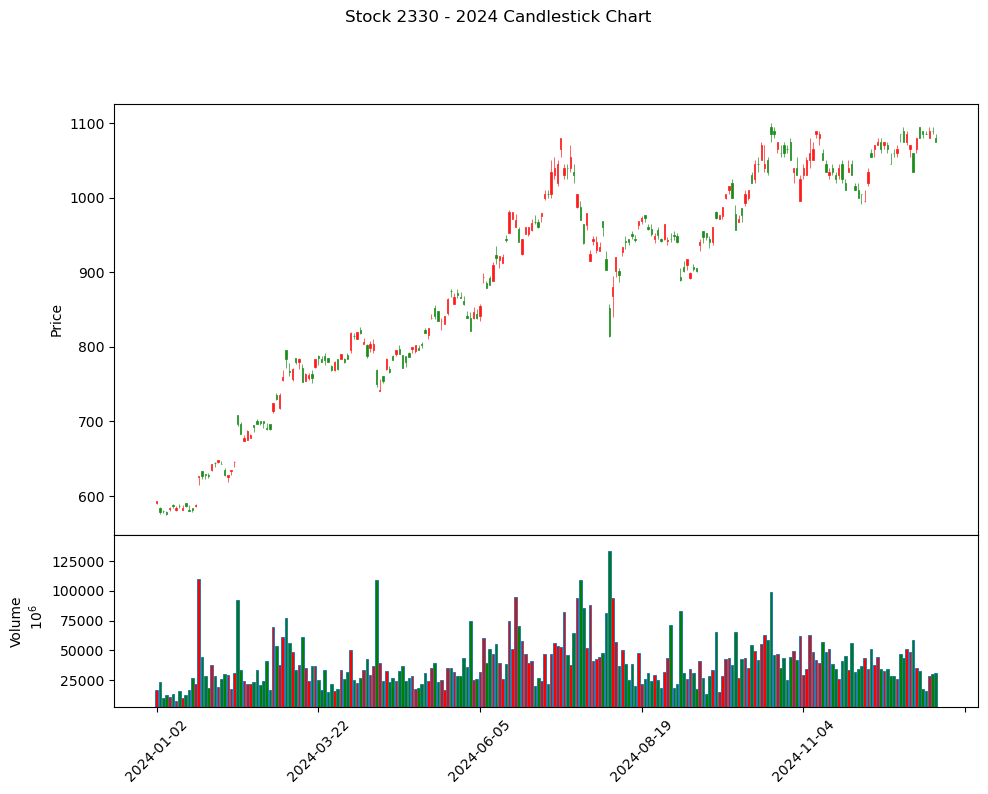

In [13]:
conn = pyodbc.connect(
    'DRIVER={SQL Server};'
    'SERVER=localhost;'  
    'DATABASE=NCU_database;'
    'UID=user;'    
    'PWD=0000'          
)

# SQL 查詢語句
query = """
SELECT [date], [Open], [High], [Low], [Close], [Volume]
FROM StockTrading_TA 
WHERE StockCode = '2330' 
AND [date] BETWEEN '2024-01-01' AND '2024-12-31'
ORDER BY [date]
"""

# 2. 讀取數據到 DataFrame
df = pd.read_sql(query, conn)

# 關閉資料庫連線
conn.close()

# 3. 重新命名欄位
df = df.rename(columns={
    'Open': 'Open',
    'High': 'High',
    'Low': 'Low',
    'Close': 'Close',
    'Volume': 'Volume'
})

# 4. 將 date 列轉為 datetime 類型
df['date'] = pd.to_datetime(df['date'])

# 5. 設定 date 為索引
df.set_index('date', inplace=True)

# 6. 設定顏色樣式 (紅漲綠跌 - 符合台灣股市習慣)
mc = mpf.make_marketcolors(
    up='red',    # 上漲用紅色
    down='green', # 下跌用綠色
    edge='inherit',
    wick='inherit',
    volume='inherit'
)

# 建立自訂樣式
s = mpf.make_mpf_style(marketcolors=mc)

# 7. 繪製 K 線圖
mpf.plot(
    df,
    type='candle',        # 繪製蠟燭圖
    style=s,             # 使用自訂顏色樣式
    title='Stock 2330 - 2024 Candlestick Chart',
    ylabel='Price',
    volume=True,         # 顯示成交量
    ylabel_lower='Volume',
    figscale=1.5,        # 圖表大小縮放
    # mav=(5, 20),        # 加入5日與20日均線
    show_nontrading=False,
    datetime_format="%Y-%m-%d"
)

# 顯示圖表
mpf.show()
